# STL-Rocket: Explanations of Time-Series Classifiers


## Setup

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, for the local (non pip-installed) stlrocket package

from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from stlrocket.data import load_dataset
from stlrocket.config import ExperimentConfig
from stlrocket.features import build_formula_bank, eval_robustness
from stlrocket.classifier import train_classifier, evaluate_classifier
from stlrocket.explanations import build_local_explanation, build_global_explanations
from stlrocket.evaluation import evaluate_local_explanation, evaluate_global

np.random.seed(42)

In [2]:
config = ExperimentConfig(
    # Dataset
    dataset = "Epilepsy",
    n_formulas = 10000,
    depth_max = 3,
    only_temporal = True,
    until_weight = 0.0,

    # Classifier
    cv = 3,

    # Explanation
    pool_size = 10,
    precision_threshold = 0.75,

    # Global explanation simplification
    simplify_agreement = 0.98,
    simplify_min_gain = 0.0,
    simplify_decimals = 1,

    # Experiment loop
    n_run = 10,
    base_seed = 0, # run i uses seed=base_seed+i

    # Explanations
    explain = True,

    # Output
    output_dir = "results",

    # Hardware
    device = "cpu"
)

## Dataset

In [3]:
X_tr_raw, y_tr, X_te_raw, y_te = load_dataset(config.dataset)
classes = np.unique(y_tr)
N, V, T = X_tr_raw.shape

In [4]:
print(f"train: {X_tr_raw.shape}")
print(f"test: {X_te_raw.shape}")
print(f"n_classes: {len(classes)}")
print(f"classes: {classes}")

train: (137, 3, 206)
test: (138, 3, 206)
n_classes: 4
classes: ['epilepsy' 'running' 'sawing' 'walking']


## Feature Extraction



In [5]:
def plot_robustness_kde(phi, X, y, classes, target_class, title=None):
    rho = eval_robustness(phi, X)
    grid = np.linspace(rho.min() - 1, rho.max() + 1, 400)
    fig, ax = plt.subplots(figsize=(8, 3.5))
    for c in classes:
        rho_c = rho[y == c]
        is_target = (c == target_class)
        if rho_c.size < 2 or np.allclose(rho_c.std(), 0):
            ax.axvline(rho_c.mean(), linestyle="--",
                       label=f"{c} (n={rho_c.size}, degenerate)")
            continue
        kde = gaussian_kde(rho_c, 0.1)
        ax.plot(grid, kde(grid),
                label=f"{c} (n={rho_c.size})")
    ax.axvline(0, color="black", linewidth=0.8, linestyle=":", label="rho = 0")
    ax.set_xlabel("rho"); ax.set_ylabel("density")
    if title is not None:
        ax.set_title(title)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

In [6]:
formulas, X_tr_feats, X_te_feats = build_formula_bank(X_tr_raw, X_te_raw, config, config.base_seed)
print("First 10 formulae")
for f in formulas[:10]:
    print(f)

First 10 formulae
( G[4,11]( ¬( F[74,92](x_0 => 0.0337) ) ) )
( ( F[180,inf]( F[0,4](x_2 <= -0.5011) ) ) ∧ (x_1 <= 0.7962) )
( ¬( ( ¬(x_0 => -2.9203) ) ∨ ( G[0,inf](x_2 => 0.2505) ) ) )
( F[52,inf]( G[73,inf](x_2 => 1.6505) ) )
( (x_0 => -3.3533) ∨ ( ( F(x_0 => 2.8589) ) ∧ ( ¬(x_2 <= 1.7135) ) ) )
( G[85,151]( ( (x_0 <= -0.9186) ∧ (x_1 <= -0.5304) ) ∨ (x_0 <= 2.5512) ) )
( ( (x_0 => 1.5661) ∧ (x_0 <= 3.1374) ) ∨ ( G[7,18](x_1 <= -1.0749) ) )
( ¬( G[16,52](x_2 <= 0.143) ) )
( ( G( (x_1 => -2.7484) ∨ (x_2 => -1.2158) ) ) ∨ ( F[79,inf](x_1 => 2.4244) ) )
( G[20,190](x_0 <= 0.3182) )


## Classifier


In [7]:
model = train_classifier(X_tr_feats, y_tr, config)
W, b = model.coef_, model.intercept_

In [8]:
train_metrics = evaluate_classifier(model, X_tr_feats, y_tr)
test_metrics = evaluate_classifier(model, X_te_feats, y_te)
print(f"Balanced accuracy train set: {train_metrics['balanced_accuracy']:.3f}")
print(f"Balanced accuracy test set: {test_metrics['balanced_accuracy']:.3f}")
print(f"Non-zero columns of W: {(W != 0).any(axis=0).sum()} / {W.shape[1]}")

Balanced accuracy train set: 1.000
Balanced accuracy test set: 0.965
Non-zero columns of W: 41 / 10000


## Local Explanations

In [9]:
formula_cache = {}
locals_per_class = defaultdict(list)

for i in range(X_tr_feats.shape[0]):
    phi_local, pred_class, picks = build_local_explanation(
        X_tr_feats[i], X_tr_raw[i:i+1], W, b, model, formulas,
        X_tr_raw, y_tr, formula_cache,
        pool_size=config.pool_size, precision_threshold=config.precision_threshold,
    )

    if phi_local is not None:
        precision, n_tp = evaluate_local_explanation(phi_local, pred_class, X_tr_raw, y_tr)
    else:
        precision, n_tp = 0.0, 0

    print(f"sample {i:>4} | pred_class={pred_class!s:>10} | true_class={y_tr[i]!s:>10} | "
          f"precision={precision:.3f} | n_tp={n_tp:>3} | "
          f"picks={picks} | formula={phi_local}")

    locals_per_class[pred_class].append([i, phi_local, picks, precision, n_tp])

print("\n" + "=" * 60)
print("PER-CLASS SUMMARY")
print("=" * 60)
for cls in sorted(locals_per_class):
    entries = locals_per_class[cls]
    n = len(entries)
    found = [e for e in entries if e[1] is not None]

    print(f"\nclass={cls}  (n={n}, with explanation={len(found)})")
    if not found:
        continue
    precisions = [p for (_, _, _, p, _) in found]
    tps = [tp for (_, _, _, _, tp) in found]
    lengths = [len(picks) for (_, _, picks, _, _) in found]
    print(f"  mean precision : {np.mean(precisions):.3f}  (std={np.std(precisions):.3f})")
    print(f"  mean n_tp      : {np.mean(tps):.1f}  (std={np.std(tps):.1f})")
    print(f"  mean length    : {np.mean(lengths):.2f}")

sample    0 | pred_class=  epilepsy | true_class=  epilepsy | precision=0.886 | n_tp= 31 | picks=[8889] | formula=( G[96,112]( (x_0 => -1.264) ∧ (x_0 <= 0.986) ) )
sample    1 | pred_class=  epilepsy | true_class=  epilepsy | precision=0.886 | n_tp= 31 | picks=[8889] | formula=( G[96,112]( (x_0 => -1.264) ∧ (x_0 <= 0.986) ) )
sample    2 | pred_class=  epilepsy | true_class=  epilepsy | precision=0.886 | n_tp= 31 | picks=[8889] | formula=( G[96,112]( (x_0 => -1.264) ∧ (x_0 <= 0.986) ) )
sample    3 | pred_class=  epilepsy | true_class=  epilepsy | precision=0.886 | n_tp= 31 | picks=[8889] | formula=( G[96,112]( (x_0 => -1.264) ∧ (x_0 <= 0.986) ) )
sample    4 | pred_class=  epilepsy | true_class=  epilepsy | precision=0.886 | n_tp= 31 | picks=[8889] | formula=( G[96,112]( (x_0 => -1.264) ∧ (x_0 <= 0.986) ) )
sample    5 | pred_class=  epilepsy | true_class=  epilepsy | precision=0.886 | n_tp= 31 | picks=[8889] | formula=( G[96,112]( (x_0 => -1.264) ∧ (x_0 <= 0.986) ) )
sample    6 | pr

# Global Explanations

In [10]:
global_per_class, locals_per_class_test, n_unique_per_class = build_global_explanations(
    X_te_feats, X_te_raw, X_tr_feats, X_tr_raw, W, b, model, formulas, y_tr,
    pool_size=config.pool_size,
    precision_threshold=config.precision_threshold,
    simplify_agreement=config.simplify_agreement,
    simplify_min_gain=config.simplify_min_gain,
    simplify_decimals=config.simplify_decimals,
)

for cls, phi in global_per_class.items():
    print(f"{cls!s:<6} (n_unique_locals={n_unique_per_class[cls]}): {phi}")

epilepsy (n_unique_locals=2): ( ( G[55,88]( (x_0 => -1.2) ∧ (x_0 <= 1.1471) ) ) ∨ ( ( ( G[2,74](x_1 <= 2.2) ) ∧ ( F(x_1 => 1.2) ) ) ∧ ( F[188,inf]( ( G[0,14](x_0 => -1.0) ) ∧ (x_1 => -0.0) ) ) ) )
walking (n_unique_locals=4): ( ( ( ( G[102,inf]( (x_1 => -0.9) ∧ (x_1 <= 1.1) ) ) ∧ ( F[41,175]( G[0,4](x_2 => 0.1) ) ) ) ∨ ( G[50,inf]( G[27,inf](x_0 => 0.2) ) ) ) ∨ ( ( G[79,inf]( (x_2 => -0.7) ∧ (x_2 <= 0.8) ) ) ∧ ( F[37,144]( G[2,17](x_0 <= -0.1475) ) ) ) )
running (n_unique_locals=2): ( ( F[80,167]( (x_1 => 2.2) ∨ (x_1 <= -2.9) ) ) ∨ ( F[96,112](x_0 => 1.8) ) )
sawing (n_unique_locals=3): ( ( G[41,175]( F[0,4](x_2 <= -0.3) ) ) ∨ ( ( G[2,inf](x_2 <= 0.2) ) ∧ ( G(x_1 <= 0.3) ) ) )


## Evaluation Global Explanations



In [11]:
def print_global_evaluation(global_per_class, X_eval, y_eval):
    results = evaluate_global(global_per_class, X_eval, y_eval)
    print(f"{'class':<12s} {'F1':>8s}")
    print("-" * 22)
    for cls in global_per_class:
        print(f"{cls!s:<12s} {results[cls]['f1']:>7.3f}")
    print(f"{'macro_avg':<12s} {results['macro_avg']['f1']:>7.3f}")


print("Evaluation on train set:")
print_global_evaluation(global_per_class, X_tr_raw, y_tr)

print("\nEvaluation on test set:")
print_global_evaluation(global_per_class, X_te_raw, y_te)

Evaluation on train set:
class              F1
----------------------
epilepsy       0.919
walking        0.946
running        0.878
sawing         0.866
macro_avg      0.902

Evaluation on test set:
class              F1
----------------------
epilepsy       0.835
walking        0.842
running        0.892
sawing         0.794
macro_avg      0.841


In [12]:
for a, b in zip(global_per_class.items(), global_per_class_tuned.items()):
    cls = a[0]
    phi_global = a[1]
    phi_global_tuned = b[1]
    print(phi_global)
    plot_robustness_kde(
        phi_global, X_tr_raw, y_tr, classes, cls,
        title=f"phi_{cls}_global on train set",
    )
    print(phi_global_tuned)
    plot_robustness_kde(
        phi_global_tuned, X_tr_raw, y_tr, classes, cls,
        title=f"phi_{cls}_global_tuned on train set",
    )

NameError: name 'global_per_class_tuned' is not defined

Evaluation on train set:
( ( ( G[96,112](x_0 => -1.2) ) ∧ ( G[134,inf]( G[62,inf](x_0 <= 0.8) ) ) ) ∨ ( ( ( G[27,34]( (x_1 <= 0.2) ∨ (x_0 <= 1.1) ) ) ∧ ( F[11,inf](x_1 => 1.2) ) ) ∧ ( F[69,inf](x_1 <= -1.2) ) ) )


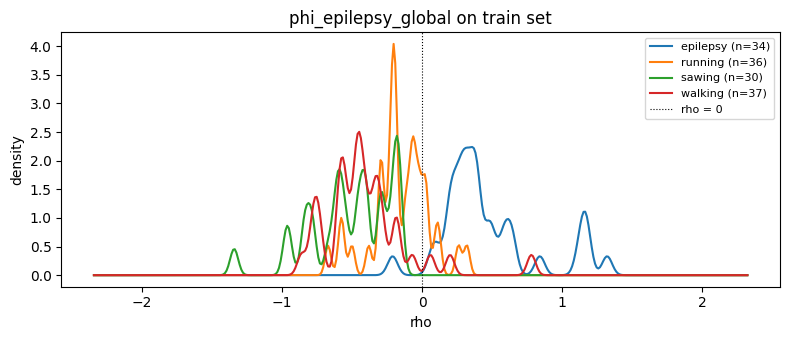

( ( ( G[28,68]( (x_2 => -0.7) ∧ (x_2 <= 0.7) ) ) ∧ ( F[36,121]( G[3,18](x_1 => -0.6) ) ) ) ∨ ( ( G[121,inf]( (x_0 <= -0.2) ∨ (x_0 => 0.4) ) ) ∧ ( G(x_1 <= 0.7) ) ) )


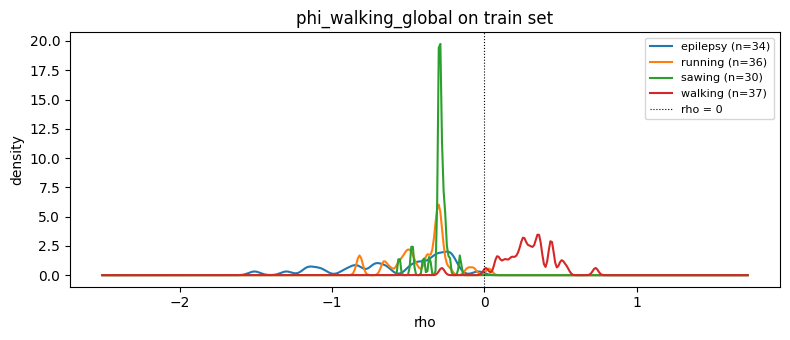

( ( F(x_0 => 2.3) ) ∨ ( F[85,inf]( (x_1 => 2.3) ∨ (x_0 <= -1.9) ) ) )


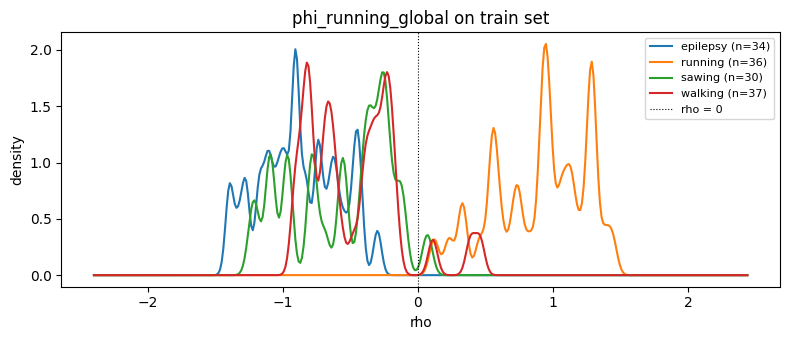

( ( ( ( G[59,131]( F[27,33](x_2 <= -0.4) ) ) ∧ ( G[13,78](x_2 <= 0.1) ) ) ∨ ( ( G[13,78]( (x_2 <= 0.1) ∨ (x_0 <= -0.8) ) ) ∧ ( G[43,152](x_1 <= 0.1) ) ) ) ∨ ( ( G[41,175]( F[0,4](x_2 <= -0.3) ) ) ∧ ( G[43,152](x_1 <= 0.1) ) ) )


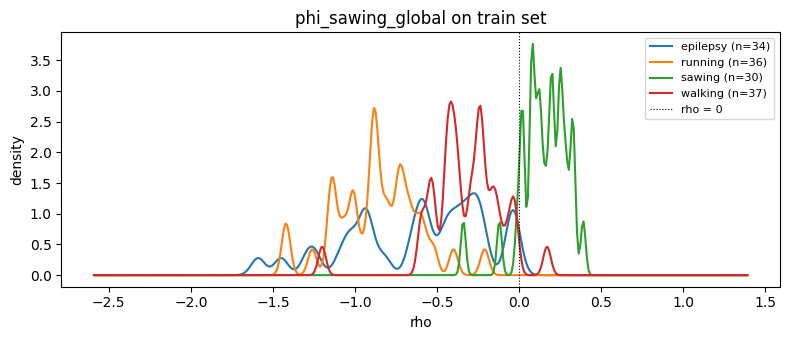


Evaluation on test set:
( ( ( G[96,112](x_0 => -1.2) ) ∧ ( G[134,inf]( G[62,inf](x_0 <= 0.8) ) ) ) ∨ ( ( ( G[27,34]( (x_1 <= 0.2) ∨ (x_0 <= 1.1) ) ) ∧ ( F[11,inf](x_1 => 1.2) ) ) ∧ ( F[69,inf](x_1 <= -1.2) ) ) )


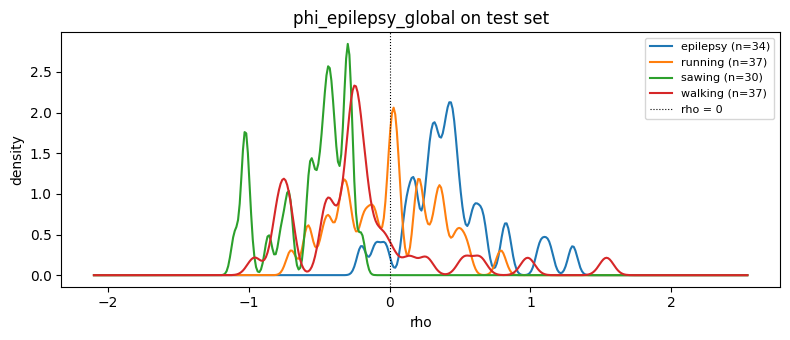

( ( ( G[28,68]( (x_2 => -0.7) ∧ (x_2 <= 0.7) ) ) ∧ ( F[36,121]( G[3,18](x_1 => -0.6) ) ) ) ∨ ( ( G[121,inf]( (x_0 <= -0.2) ∨ (x_0 => 0.4) ) ) ∧ ( G(x_1 <= 0.7) ) ) )


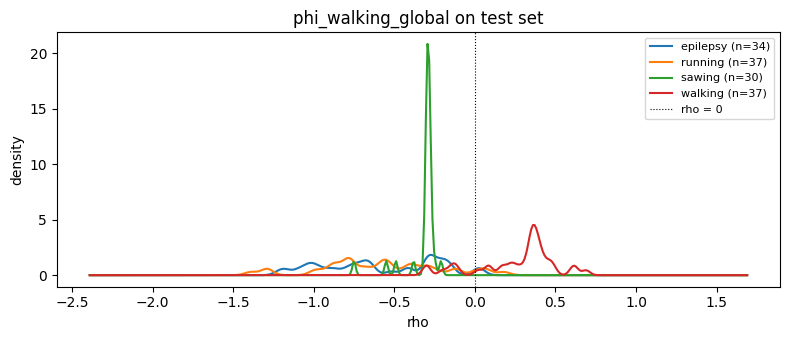

( ( F(x_0 => 2.3) ) ∨ ( F[85,inf]( (x_1 => 2.3) ∨ (x_0 <= -1.9) ) ) )


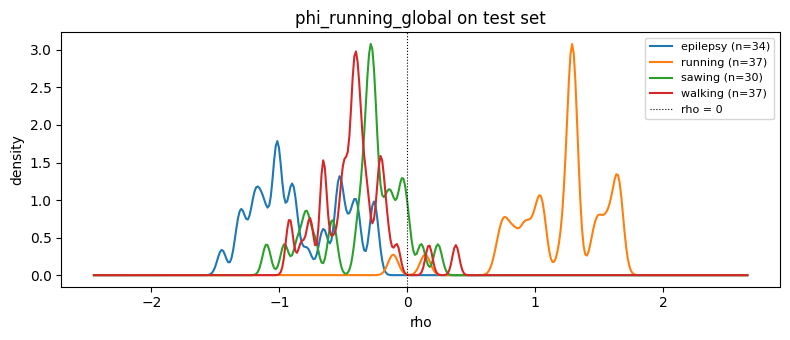

( ( ( ( G[59,131]( F[27,33](x_2 <= -0.4) ) ) ∧ ( G[13,78](x_2 <= 0.1) ) ) ∨ ( ( G[13,78]( (x_2 <= 0.1) ∨ (x_0 <= -0.8) ) ) ∧ ( G[43,152](x_1 <= 0.1) ) ) ) ∨ ( ( G[41,175]( F[0,4](x_2 <= -0.3) ) ) ∧ ( G[43,152](x_1 <= 0.1) ) ) )


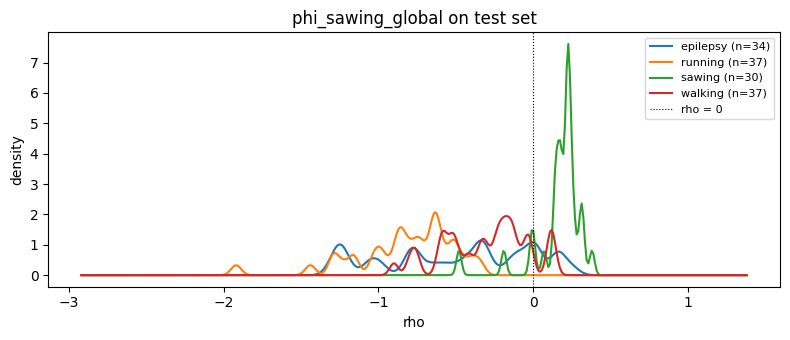

In [ ]:
print("Evaluation on train set:")
for cls, phi_global in global_per_class.items():
    print(phi_global)
    plot_robustness_kde(
        phi_global, X_tr_raw, y_tr, classes, cls,
        title=f"phi_{cls}_global on train set",
    )

print("\nEvaluation on test set:")
for cls, phi_global in global_per_class.items():
    print(phi_global)
    plot_robustness_kde(
        phi_global, X_te_raw, y_te, classes, cls,
        title=f"phi_{cls}_global on test set",
    )